In [106]:
import csv
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split
import tensorflow as tf
import mediapipe as mp
from sklearn.metrics import confusion_matrix
import numpy as np


In [107]:
# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose

# Directory for TensorFlow.js model
#tfjs_model_dir = 'model'


In [108]:
# Load CSV file
def load_csv(csv_path):
    df = pd.read_csv(csv_path)
    df.drop(df.columns[0], axis=1, inplace=True)  # Drop filename column
    class_names = df['class_name'].unique().tolist()
    df['class_no'] = df['class_name'].apply(lambda x: class_names.index(x))
    y = keras.utils.to_categorical(df.pop('class_no'))
    X = df.iloc[:, :-1].astype('float64')  # Exclude class_name column
    return X, y, class_names

In [109]:
# Get center point method (Hip and Shoulder Center)
def get_center_point(landmarks, hip_left_idx, hip_right_idx, shoulder_left_idx, shoulder_right_idx):
    hip_center = (landmarks[hip_left_idx][:2] + landmarks[hip_right_idx][:2]) / 2
    shoulder_center = (landmarks[shoulder_left_idx][:2] + landmarks[shoulder_right_idx][:2]) / 2
    center = (hip_center + shoulder_center) / 2
    return center

In [110]:
# Get pose size with torso size multiplier
def get_pose_size(landmarks, torso_size_multiplier=2.5):
    pose_center = get_center_point(landmarks, 
                                   mp_pose.PoseLandmark.LEFT_HIP.value, 
                                   mp_pose.PoseLandmark.RIGHT_HIP.value, 
                                   mp_pose.PoseLandmark.LEFT_SHOULDER.value, 
                                   mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
    
    hip_center = (landmarks[mp_pose.PoseLandmark.LEFT_HIP.value][:2] + landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value][:2]) / 2
    shoulder_center = (landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value][:2] + landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value][:2]) / 2
    torso_size = tf.norm(shoulder_center - hip_center)
    
    pose_size = tf.maximum(torso_size * torso_size_multiplier, tf.reduce_max(tf.norm(landmarks - pose_center, axis=1)))
    return pose_size


In [111]:
# Normalize pose landmarks (updated method)
def normalize_pose_landmarks(landmarks):
    landmarks = tf.convert_to_tensor(landmarks, dtype=tf.float32)
    pose_center = get_center_point(landmarks, 
                                   mp_pose.PoseLandmark.LEFT_HIP.value, 
                                   mp_pose.PoseLandmark.RIGHT_HIP.value, 
                                   mp_pose.PoseLandmark.LEFT_SHOULDER.value, 
                                   mp_pose.PoseLandmark.RIGHT_SHOULDER.value)
    landmarks = landmarks[:, :2] - pose_center  # Normalize to hip and shoulder center
    pose_size = get_pose_size(landmarks)
    landmarks /= pose_size  # Scale landmarks
    return landmarks

In [112]:
# Convert landmarks to embeddings
def landmarks_to_embedding(landmarks):
    normalized_landmarks = normalize_pose_landmarks(landmarks)
    embedding = tf.reshape(normalized_landmarks, [-1])
    return embedding

In [113]:
# Preprocess dataset
def preprocess_data(X_data):
    processed_X = []
    for i in range(X_data.shape[0]):
        embedding = landmarks_to_embedding(X_data.iloc[i].values.reshape(33, 3))
        processed_X.append(embedding)
    return tf.convert_to_tensor(processed_X)

In [114]:
# Load and process data
X, y, class_names = load_csv('train_data.csv')
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
X_test, y_test, _ = load_csv('test_data.csv')

processed_X_train = preprocess_data(X_train)
processed_X_val = preprocess_data(X_val)
processed_X_test = preprocess_data(X_test)

In [115]:
# Build Model
inputs = tf.keras.Input(shape=(66,))  # 33 landmarks * 2 (x, y normalized)
layer = keras.layers.Dense(256, activation='relu')(inputs)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(128, activation='relu')(layer)
layer = keras.layers.Dropout(0.5)(layer)
outputs = keras.layers.Dense(len(class_names), activation='softmax')(layer)

model = keras.Model(inputs, outputs)

In [116]:
# Compile Model
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [117]:
# Callbacks
checkpoint_path = "weights.best.keras"
checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path,
                                             monitor='val_accuracy',
                                             verbose=1,
                                             save_best_only=True,
                                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=40)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                              factor=0.5,
                                              patience=5,
                                              min_lr=1e-6)

In [118]:
# Train Model
print('--------------TRAINING----------------')
history = model.fit(processed_X_train, y_train,
                    epochs=250,
                    batch_size=16,
                    validation_data=(processed_X_val, y_val),
                    callbacks=[checkpoint, earlystopping])

--------------TRAINING----------------
Epoch 1/250
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2297 - loss: 1.8742
Epoch 1: val_accuracy improved from -inf to 0.60770, saving model to weights.best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2300 - loss: 1.8738 - val_accuracy: 0.6077 - val_loss: 1.4575
Epoch 2/250
226/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4606 - loss: 1.4696
Epoch 2: val_accuracy improved from 0.60770 to 0.68474, saving model to weights.best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4634 - loss: 1.4616 - val_accuracy: 0.6847 - val_loss: 1.0751
Epoch 3/250
227/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5567 - loss: 1.1998
Epoch 3: val_accuracy improved from 0.68474 to 0.77175, saving model to weights.best.keras
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5579 - loss: 1.1957 - val_accuracy: 0.7718 - val_loss: 0.9137
Epoch 4/250
239/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6090 - loss:

In [119]:
# Get true labels (convert one-hot encoding to class indices)
y_true_classes = np.argmax(y_test, axis=1)

# Get predicted labels
y_pred = model.predict(processed_X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


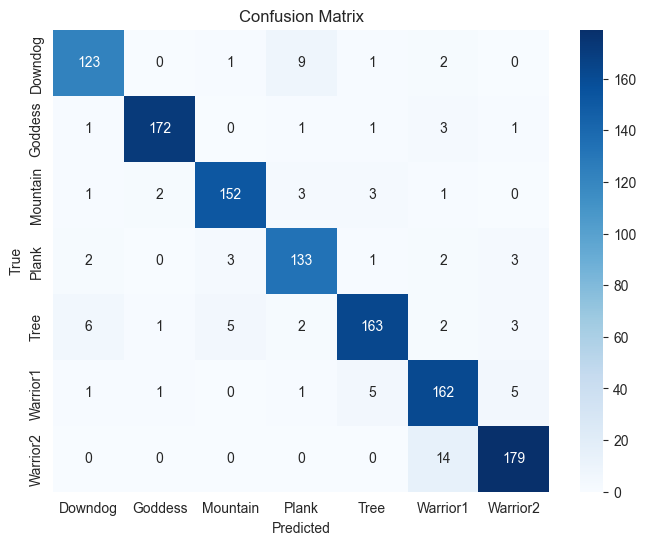

In [120]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [121]:
from sklearn.metrics import classification_report

# Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

     Downdog       0.92      0.90      0.91       136
     Goddess       0.98      0.96      0.97       179
    Mountain       0.94      0.94      0.94       162
       Plank       0.89      0.92      0.91       144
        Tree       0.94      0.90      0.92       182
    Warrior1       0.87      0.93      0.90       175
    Warrior2       0.94      0.93      0.93       193

    accuracy                           0.93      1171
   macro avg       0.93      0.93      0.92      1171
weighted avg       0.93      0.93      0.93      1171



In [122]:
# Evaluate Model
print('-----------------EVALUATION----------------')
loss, accuracy = model.evaluate(processed_X_test, y_test)
print('LOSS:', loss)
print('ACCURACY:', accuracy)

# Save Model for TensorFlow.js
#tfjs.converters.save_keras_model(model, tfjs_model_dir)
#print('tfjs model saved at', tfjs_model_dir)


-----------------EVALUATION----------------
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9251 - loss: 0.4824
LOSS: 0.4622623920440674
ACCURACY: 0.9257045388221741


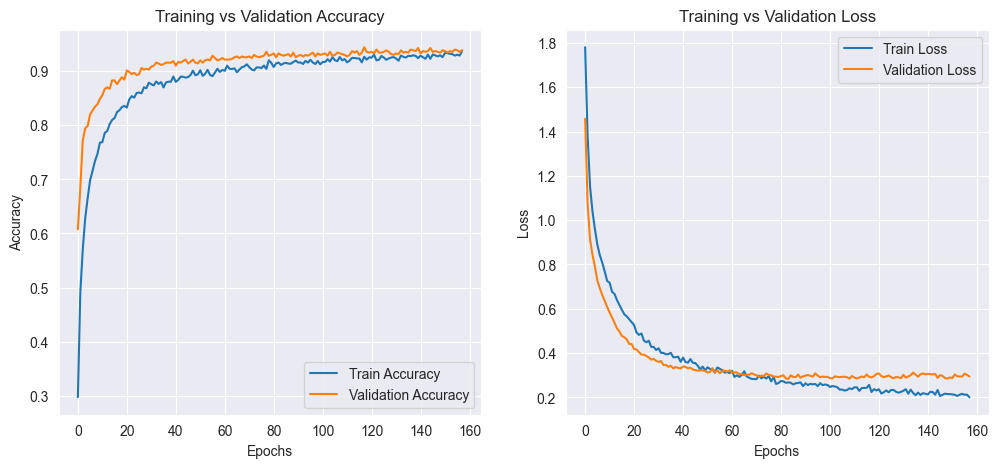

In [123]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


Check predictions are correct or not

In [154]:
import numpy as np
import tensorflow as tf

# Function to process user input
def process_user_input(landmarks):
    landmarks = np.array(landmarks).reshape(33, 3)  # Convert to (33, 3) shape
    embedding = landmarks_to_embedding(landmarks)  # Convert to embedding
    return tf.convert_to_tensor([embedding], dtype=tf.float32)  # Model expects batch input

# Function to make a prediction
def predict_pose_class(user_landmarks):
    processed_input = process_user_input(user_landmarks)
    
    # Get prediction probabilities
    predictions = model.predict(processed_input)
    
    # Get the predicted class and confidence score
    predicted_class_index = np.argmax(predictions)
    confidence = np.max(predictions) * 100  # Convert to percentage
    predicted_class = class_names[predicted_class_index]

    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

# Example User Input (Replace with actual values)
user_landmarks = [
    [0.59518903, 0.73367816, 0.9965249], [0.6220079, 0.7312716, 0.9982578], [0.6242743, 0.72876585, 0.99777466],
    [0.6266024, 0.72597134, 0.99762815], [0.62303483, 0.7309998, 0.9974026], [0.62584305, 0.7285621, 0.9968406],
    [0.6285342, 0.72596216, 0.9963875], [0.6452934, 0.69235307, 0.99859005], [0.64200974, 0.6977593, 0.99876106],
    [0.5887263, 0.71430856, 0.99387], [0.59124, 0.7140707, 0.99358785], [0.6106199, 0.60540783, 0.9933402],
    [0.60540533, 0.62822676, 0.99874264], [0.74955606, 0.6711397, 0.19534989], [0.7389337, 0.7096875, 0.987351],
    [0.85855556, 0.7111857, 0.41389227], [0.8818153, 0.74975914, 0.9829056], [0.8967329, 0.70900893, 0.4165431],
    [0.92098844, 0.7585788, 0.9735155], [0.90157735, 0.7120889, 0.4042725], [0.9251063, 0.75682735, 0.96840066],
    [0.88679516, 0.7123803, 0.4402542], [0.9127934, 0.7518923, 0.95775366], [0.3798315, 0.38179344, 0.9985475],
    [0.4351636, 0.35834417, 0.99855536], [0.124200016, 0.4781732, 0.93452233], [0.54406595, 0.11598283, 0.9973496],
    [0.04956931, 0.3488763, 0.80451494], [0.664389, 0.03609276, 0.9627481], [0.06615254, 0.31456792, 0.71370345],
    [0.69451046, 0.03867495, 0.9248294], [-0.022636503, 0.3364103, 0.603655], [0.70433724, -0.051560104, 0.85613567]
]



# Predict class for the example input
predict_pose_class(user_landmarks)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Class: Warrior1
Confidence: 96.30%


In [155]:
# Save Model in keras format
model.save('pose_estimation_model.keras')
print('Model saved in .keras format at pose_estimation_model.keras')

Model saved in .keras format at pose_estimation_model.keras


In [156]:
# Save Model in H5 format
model.save('pose_estimation_model.h5')
print('Model saved in .H5 format at pose_estimation_model.H5')

Model saved in .H5 format at pose_estimation_model.H5
